# EffNet non Bayésien

In [1]:
import torch
import torchvision
import numpy as np
from torchvision.transforms import v2
import matplotlib.pyplot as plt

import torch.nn as nn
import torch.nn.functional as F

### Fonctions usuelles

In [2]:
def predictive_entropy(output):
    if output.ndim == 3:
        mean_output = np.mean(output, axis=0)
        return -np.sum(mean_output * np.log(mean_output + 1e-10), axis=-1)
    return -np.sum(output * np.log(output + 1e-10), axis=-1)

def mutual_information(output):
    if output.ndim == 3:
        mean_output = np.mean(output, axis=0)
        entropy = -np.sum(mean_output * np.log(mean_output + 1e-10), axis=-1)
        expected_entropy = -np.mean(np.sum(output * np.log(output + 1e-10), axis=-1), axis=0)
        return entropy - expected_entropy
    return np.zeros(output.shape[0], dtype=float)

### Hyperparamètres

In [3]:
learning_rate = 0.001
nb_epoch = 50
batch_size = 128
milestones = [20, 35, 45]
gamma = 0.5

### Load Dataset

In [4]:
from medmnist import PathMNIST
from medmnist import INFO

transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

info = INFO['pathmnist']

trainset = PathMNIST(split="train", download=True, size=28, transform=transform)
valset   = PathMNIST(split="val",   download=True, size=28, transform=transform)
testset  = PathMNIST(split="test",  download=True, size=28, transform=transform)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True,  num_workers=4, pin_memory=True)
valloader   = torch.utils.data.DataLoader(valset,   batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)
testloader  = torch.utils.data.DataLoader(testset,  batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

class_names = info['label']
print(f"class names: {class_names}")

class names: {'0': 'adipose', '1': 'background', '2': 'debris', '3': 'lymphocytes', '4': 'mucus', '5': 'smooth muscle', '6': 'normal colon mucosa', '7': 'cancer-associated stroma', '8': 'colorectal adenocarcinoma epithelium'}


#### Use GPU

In [5]:
device = torch.device(torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else 'cpu')

### Créée le réseau

In [6]:
net = torchvision.models.efficientnet_b0(progress = True)
net.classifier[1] = nn.Linear(1280, 9)
net.to(device)

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

### Training

In [7]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(net.parameters(), lr=learning_rate)
scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=milestones, gamma=gamma)

In [8]:
print(device)

train_losses = []
val_losses = []

for epoch in range (nb_epoch) :
    net.train()
    running_loss_train = 0.0
    for i, data in enumerate(trainloader, 0):
        inputs, labels = data[0].to(device), data[1].to(device)
        labels = labels.squeeze(1)
        optimizer.zero_grad()

        outputs = net(inputs)
        loss_train = criterion(outputs, labels)
        loss_train.backward()
        optimizer.step()

        running_loss_train += loss_train.item()


    scheduler.step()

    # Validation
    net.eval()
    running_loss_val = 0.0
    with torch.no_grad():
        for i, data in enumerate(valloader, 0):
            inputs, labels = data[0].to(device), data[1].to(device)
            labels = labels.squeeze(1)
            outputs = net(inputs)
            loss_val = criterion(outputs, labels)
            running_loss_val += loss_val.item()

    train_losses.append(running_loss_train / len(trainloader))
    val_losses.append(running_loss_val / len(valloader))

    print(f'[{epoch + 1}] val loss: {running_loss_val / len(valloader):.3f}')
    print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss_train / len(trainloader):.3f}')

torch.save({
    'model_state_dict': net.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'train_losses': train_losses,
    'val_losses': val_losses,
}, "effnet_de_base.pth")

print('Finished Training')

cuda
[1] val loss: 0.834
[1,    79] loss: 0.925
[2] val loss: 0.463
[2,    79] loss: 0.522
[3] val loss: 0.348
[3,    79] loss: 0.384
[4] val loss: 0.299
[4,    79] loss: 0.308
[5] val loss: 0.389
[5,    79] loss: 0.262
[6] val loss: 0.233
[6,    79] loss: 0.226
[7] val loss: 0.400
[7,    79] loss: 0.197
[8] val loss: 0.247
[8,    79] loss: 0.174
[9] val loss: 0.169
[9,    79] loss: 0.165
[10] val loss: 0.153
[10,    79] loss: 0.150
[11] val loss: 0.153
[11,    79] loss: 0.133
[12] val loss: 0.199
[12,    79] loss: 0.126
[13] val loss: 0.120
[13,    79] loss: 0.158
[14] val loss: 0.297
[14,    79] loss: 0.114
[15] val loss: 0.217
[15,    79] loss: 0.105
[16] val loss: 0.140
[16,    79] loss: 0.090
[17] val loss: 0.241
[17,    79] loss: 0.089
[18] val loss: 0.127
[18,    79] loss: 0.158
[19] val loss: 0.122
[19,    79] loss: 0.094
[20] val loss: 0.107
[20,    79] loss: 0.099
[21] val loss: 0.088
[21,    79] loss: 0.057
[22] val loss: 0.094
[22,    79] loss: 0.044
[23] val loss: 0.127
[2

### Load Modèle

### Calcul accuracy

In [9]:
correct_test = 0
correct_train = 0
correct_val = 0

total_test = 0
total_train = 0
total_val = 0

all_preds = []
all_labels = []
all_outputs = []

with torch.no_grad():
    for data in testloader:
        images, labels = data[0].to(device), data[1].to(device)
        labels = labels.squeeze(1)

        outputs = net(images)

        _, predicted = torch.max(outputs, 1)
        total_test += labels.size(0)
        correct_test += (predicted == labels).sum().item()

        all_preds.append(predicted.cpu().numpy())
        all_labels.append(labels.cpu().numpy())
        probs = torch.nn.functional.softmax(outputs, dim=-1)
        all_outputs.append(probs.cpu().numpy())

with torch.no_grad():
    for data in trainloader:
        images, labels = data[0].to(device), data[1].to(device)
        labels = labels.squeeze(1)

        outputs = net(images)

        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

with torch.no_grad():
    for data in valloader:
        images, labels = data[0].to(device), data[1].to(device)
        labels = labels.squeeze(1)

        outputs = net(images)

        _, predicted = torch.max(outputs, 1)
        total_val += labels.size(0)
        correct_val += (predicted == labels).sum().item()

all_preds = np.concatenate(all_preds, axis=0)
all_labels = np.concatenate(all_labels, axis=0)
all_outputs = np.concatenate(all_outputs, axis=0)

test_acc = correct_test / total_test * 100
val_acc = correct_val / total_val * 100
train_acc = correct_train / total_train * 100

print(f'Accuracy of the network on the test images: {test_acc:.2f} %')
print(f'Accuracy of the network on the train images: {train_acc:.2f} %')
print(f'Accuracy of the network on the validation images: {val_acc:.2f} %')


Accuracy of the network on the test images: 76.38 %
Accuracy of the network on the train images: 99.76 %
Accuracy of the network on the validation images: 97.18 %


### Accuracy par classe

In [10]:
# prepare to count predictions for each class
class_name_2 = list(class_names.values())
correct_pred = {classname: 0 for classname in class_name_2}
total_pred = {classname: 0 for classname in class_name_2}

# again no gradients needed
with torch.no_grad():
    for data in testloader:
        images, labels = data[0].to(device), data[1].to(device)
        labels = labels.squeeze(1)
        outputs = net(images)
        _, predictions = torch.max(outputs, 1)
        # collect the correct predictions for each class
        for label, prediction in zip(labels, predictions):
            name = class_names[str(label.item())]
            if label == prediction:
                correct_pred[name] += 1
            total_pred[name] += 1


# print accuracy for each class
for classname, correct_count in correct_pred.items():
    accuracy = 100 * float(correct_count) / total_pred[classname]
    print(f'Accuracy for class: {classname:5s} is {accuracy:.1f} %')

Accuracy for class: adipose is 61.0 %
Accuracy for class: background is 100.0 %
Accuracy for class: debris is 39.8 %
Accuracy for class: lymphocytes is 92.6 %
Accuracy for class: mucus is 78.5 %
Accuracy for class: smooth muscle is 77.5 %
Accuracy for class: normal colon mucosa is 72.3 %
Accuracy for class: cancer-associated stroma is 30.2 %
Accuracy for class: colorectal adenocarcinoma epithelium is 94.5 %


### Plot TrainLoss et ValLoss

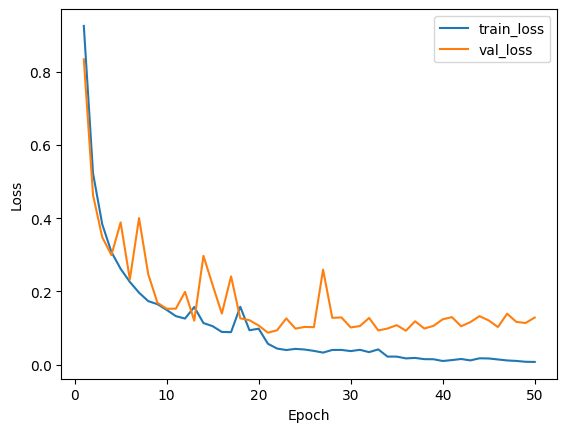

In [11]:
plt.plot(range(1, len(train_losses) + 1), train_losses, label='train_loss')
plt.plot(range(1, len(val_losses) + 1), val_losses, label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

### Plot la calibration

ECE : 19.22 %


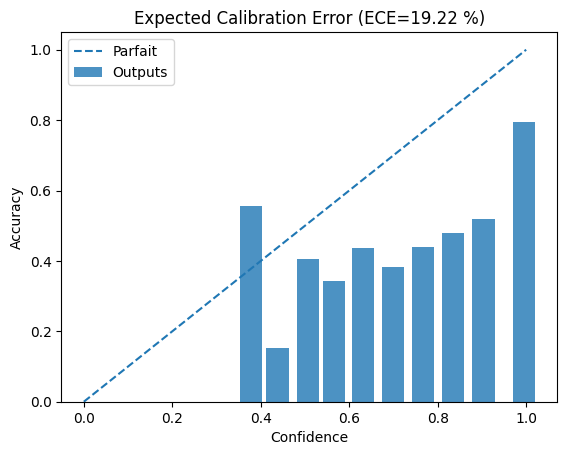

In [12]:
confidences = all_outputs.max(axis=-1)  
correct = (all_preds == all_labels).astype(float)

n_bins = 15
bin_boundaries = np.linspace(0, 1, n_bins + 1)
bin_acc = []
bin_conf = []
bin_sizes = []

for i in range(n_bins):
    mask = (confidences >= bin_boundaries[i]) & (confidences < bin_boundaries[i+1])
    if mask.sum() > 0:
        bin_acc.append(correct[mask].mean())
        bin_conf.append(confidences[mask].mean())
        bin_sizes.append(mask.sum())

#ECE
ece = sum(s * abs(a - c) for s, a, c in zip(bin_sizes, bin_acc, bin_conf)) / len(all_labels)
print(f'ECE : {100 * ece:.2f} %')

#Reliability diagram
plt.bar(bin_conf, bin_acc, width=0.05, alpha=0.8, label='Outputs')
plt.plot([0,1],[0,1], '--', label='Parfait')
plt.xlabel('Confidence')
plt.ylabel('Accuracy')
plt.title(f'Expected Calibration Error (ECE={100 * ece:.2f} %)')
plt.legend()
plt.show()

### Plot Uncertain when Inaccurate + Confidence vs Accuracy

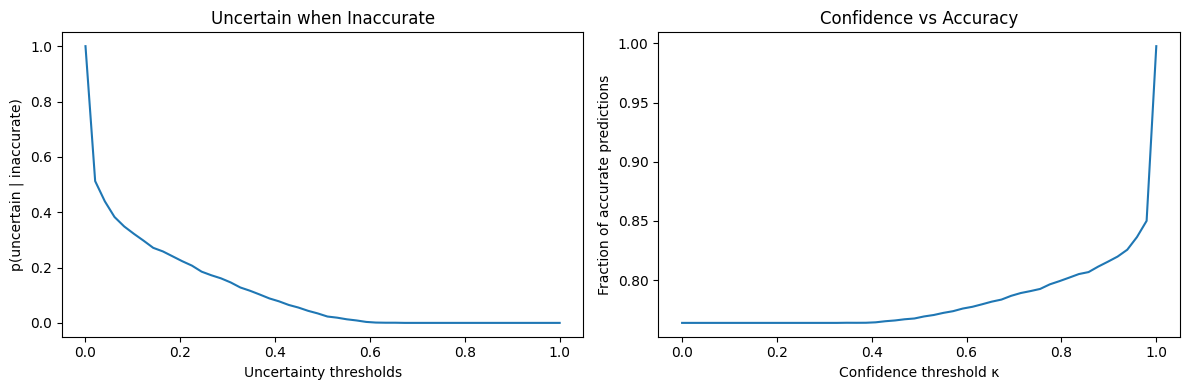

In [13]:
# Pour un réseau déterministe : incertitude = 1 - confidence
predictive_uncertainty = 1 - confidences

# Normalise entre 0 et 1 (déjà le cas puisque confidence ∈ [0,1])
unc_norm = predictive_uncertainty  # pas besoin de diviser

thresholds_unc = np.linspace(0, 1, 50)
uncertain_when_inaccurate = []
inaccurate = (correct == 0)

for kappa in thresholds_unc:
    above_threshold = unc_norm >= kappa
    if inaccurate.sum() > 0:
        uncertain_when_inaccurate.append(
            (inaccurate & above_threshold).sum() / inaccurate.sum()
        )
    else:
        uncertain_when_inaccurate.append(np.nan)

thresholds_conf = np.linspace(0, 1, 50)
confident_when_accurate = []
for kappa in thresholds_conf:
    mask = confidences >= kappa
    if mask.sum() > 0:
        confident_when_accurate.append(correct[mask].mean())
    else:
        confident_when_accurate.append(np.nan)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(thresholds_unc, uncertain_when_inaccurate)
axes[0].set_xlabel('Uncertainty thresholds')
axes[0].set_ylabel('p(uncertain | inaccurate)')
axes[0].set_title('Uncertain when Inaccurate')

axes[1].plot(thresholds_conf, confident_when_accurate)
axes[1].set_xlabel('Confidence threshold κ')
axes[1].set_ylabel('Fraction of accurate predictions')
axes[1].set_title('Confidence vs Accuracy')

plt.tight_layout()
plt.show()

### UCE (uncertain calibration error)

UCE : 15.67%


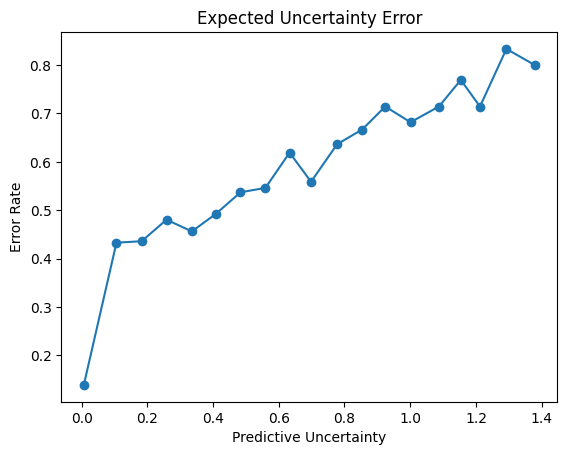

In [14]:
predictive_uncertainty = predictive_entropy(all_outputs)
errors = (all_preds != all_labels).astype(float)

n_bins = 20
bins = np.linspace(predictive_uncertainty.min(), predictive_uncertainty.max(), n_bins)
bin_idx = np.digitize(predictive_uncertainty, bins)

bin_uncertainty = []
bin_error = []
for b in range(1, n_bins):
    mask = bin_idx == b
    if mask.sum() > 0:
        bin_uncertainty.append(predictive_uncertainty[mask].mean())
        bin_error.append(errors[mask].mean())

unc_min = predictive_uncertainty.min()
unc_max = predictive_uncertainty.max()
unc_normalized = [(u - unc_min) / (unc_max - unc_min) for u in bin_uncertainty]
bin_sizes = [((bin_idx == b)).sum() for b in range(1, n_bins) if (bin_idx == b).sum() > 0]

uce = sum(
    s * abs(e - u)
    for s, e, u in zip(bin_sizes, bin_error, unc_normalized)
) / len(all_labels)

print(f'UCE : {100*uce:.2f}%')

plt.plot(bin_uncertainty, bin_error, marker='o')
plt.xlabel('Predictive Uncertainty')
plt.ylabel("Error Rate")
plt.title('Expected Uncertainty Error')
plt.show()

### Adaptative calibration error (ACE)

auce : 15.51%


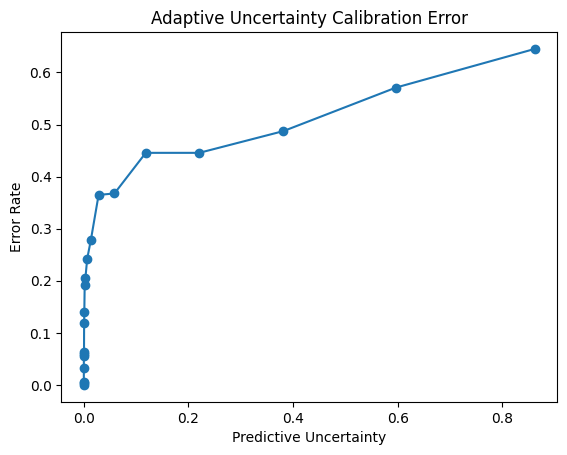

In [15]:
predictive_uncertainty = predictive_entropy(all_outputs)
errors = (all_preds != all_labels).astype(float)

n_bins = 20
# bins adaptatifs — même nombre d'exemples par bin
bin_boundaries = np.percentile(predictive_uncertainty, np.linspace(0, 100, n_bins + 1))
bin_idx = np.digitize(predictive_uncertainty, bin_boundaries)

bin_uncertainty = []
bin_error = []
for b in range(1, n_bins + 1):
    mask = bin_idx == b
    if mask.sum() > 0:
        bin_uncertainty.append(predictive_uncertainty[mask].mean())
        bin_error.append(errors[mask].mean())

unc_min = predictive_uncertainty.min()
unc_max = predictive_uncertainty.max()
unc_normalized = [(u - unc_min) / (unc_max - unc_min) for u in bin_uncertainty]
bin_sizes = [((bin_idx == b)).sum() for b in range(1, n_bins + 1) if (bin_idx == b).sum() > 0]

auce = sum(
    s * abs(e - u)
    for s, e, u in zip(bin_sizes, bin_error, unc_normalized)
) / len(all_labels)

print(f'auce : {100*ace:.2f}%')

plt.plot(bin_uncertainty, bin_error, marker='o')
plt.xlabel('Predictive Uncertainty')
plt.ylabel("Error Rate")
plt.title('Adaptive Uncertainty Calibration Error')
plt.show()

### Exporte les résultats

0.114740945
[tracker] ✓ Run 'run_effnet_sinBayesian' sauvegardé
          JSON → /home/a992250/bnn/bnn_runs.json
          CSV  → /home/a992250/bnn/bnn_runs.csv
          Accuracy=76.38%  ECE=19.22%  H=0.1147  MI=0.0000
Nom                                             Acc%   ECE%       H      MI  σ prior  ρ_init  MOPED
-----------------------------------------------------------------------------------------------
run_effnet_sinBayesian                         76.38  19.22  0.1147  0.0000     0.0     0.0  non
run_effnet_sinBayesian                         80.70  13.21  0.1617  0.0000     0.0     0.0  non


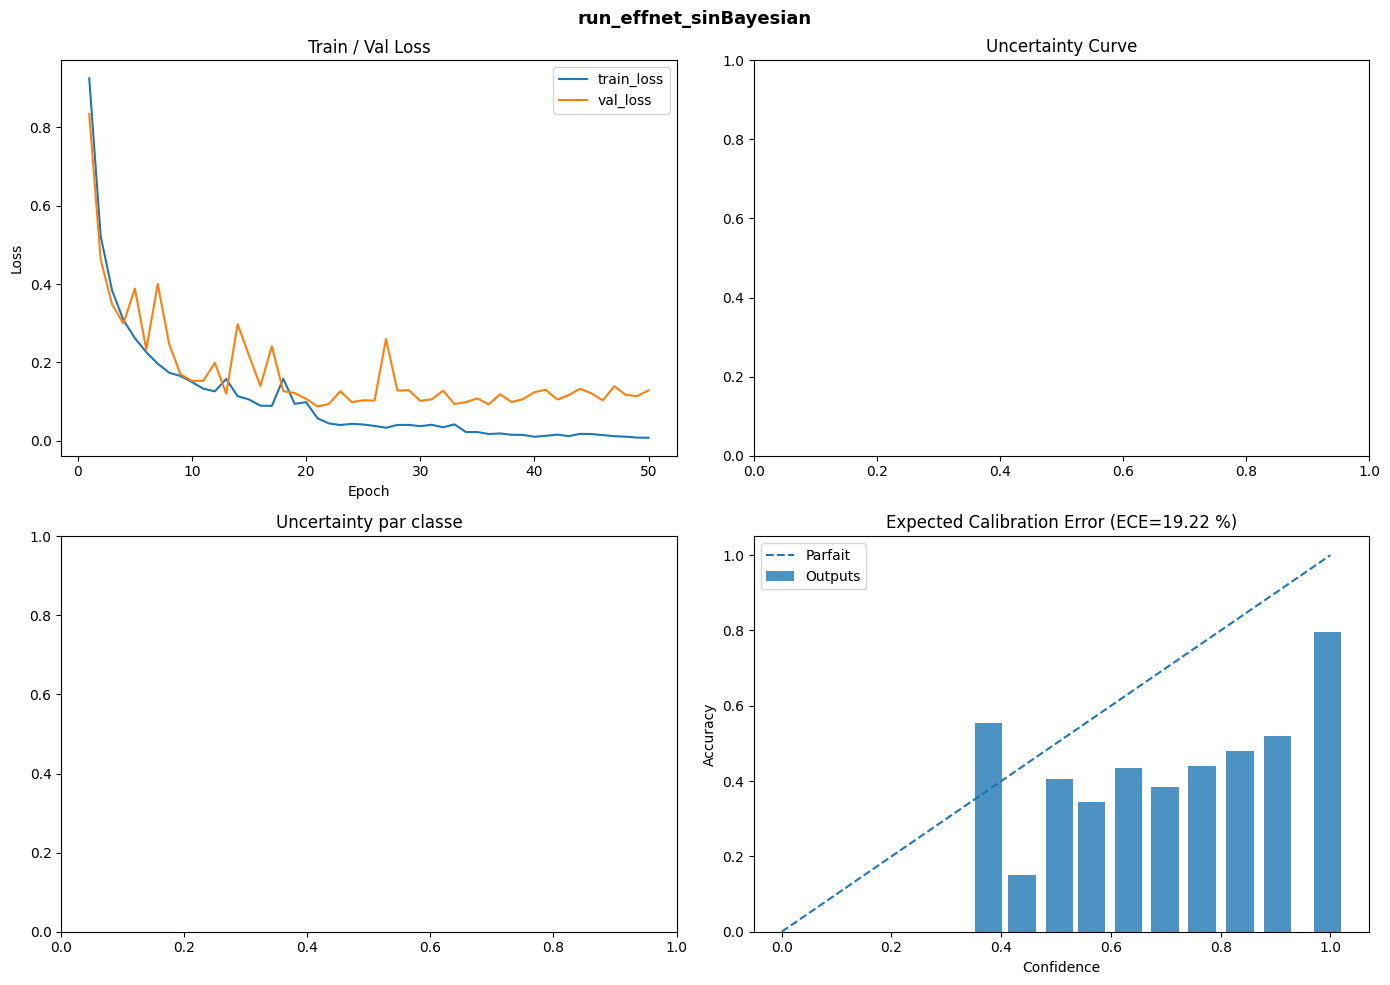

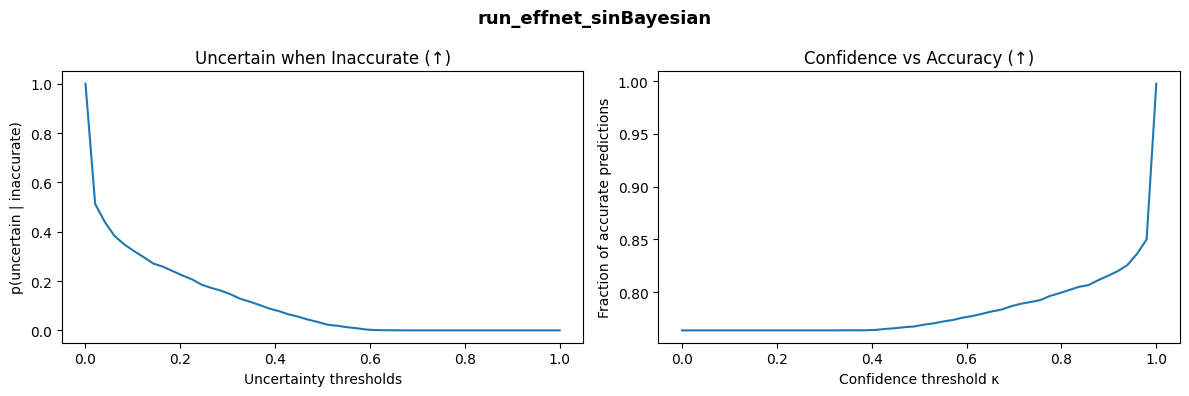

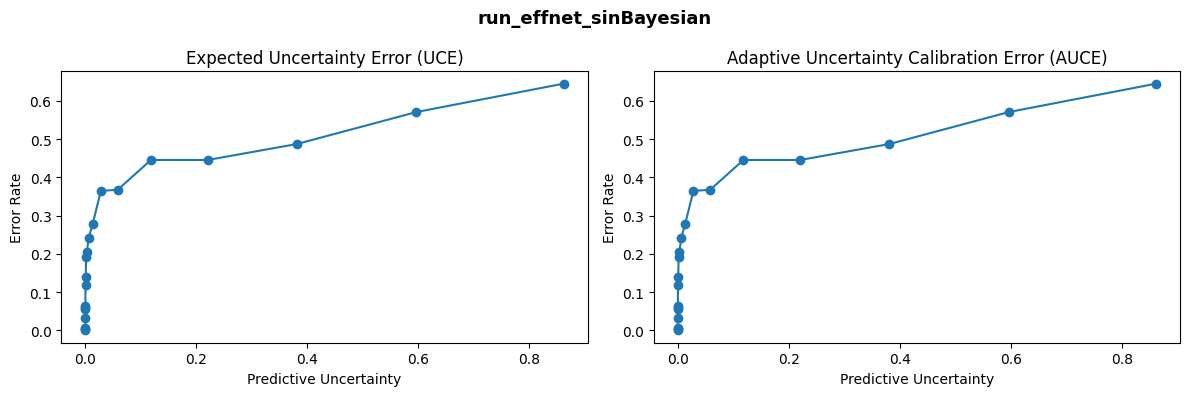

In [ ]:
import importlib
import jupyterToTracker
importlib.reload(jupyterToTracker)

from jupyterToTracker import log_run, print_summary, plot_run

# Calcule les accuracy par classe en % d'abord
class_acc_pct = {
    name: 100 * correct_pred[name] / total_pred[name]
    for name in correct_pred
}

print(predictive_uncertainty.mean())

name=f"run_effnet_sinBayesian"

log_run(
    name=name,
    # hyperparamètres
    lr=learning_rate,
    epochs=nb_epoch,
    batch_size=batch_size,
    milestones=milestones,
    gamma=gamma,
    # métriques
    test_accuracy=test_acc,
    train_accuracy=train_acc,
    val_accuracy=val_acc,
    ece=ece * 100,
    mean_predictive_entropy=float(predictive_uncertainty.mean()),
    uce=uce * 100,
    ace=auce * 100,
    auce=auce * 100,
    # classes
    class_accuracy=class_acc_pct,
    notes="premier test baseline",
    # plots
    train_losses=train_losses,
    val_losses=val_losses,
    calib_bin_conf=bin_conf,
    calib_bin_acc=bin_acc,
    calib_bin_sizes=bin_sizes,
    thresholds_unc=thresholds_unc.tolist(),
    uncertain_when_inaccurate=uncertain_when_inaccurate,
    thresholds_conf=thresholds_conf.tolist(),
    confident_when_accurate=confident_when_accurate,
    ace_bin_confidence=bin_conf,
    ace_bin_accuracy=bin_acc,
    uce_bin_uncertainty=bin_uncertainty,   # du plot UCE
    uce_bin_error=bin_error,
    auce_bin_uncertainty=bin_uncertainty,  # du plot AUCE (recalculé avec bins adaptatifs)
    auce_bin_error=bin_error,
)

print_summary()
plot_run(name)